### 手写数字

In [65]:
from sklearn.datasets import load_digits  # 导入手写数字数据集加载函数
digits = load_digits()  # 加载手写数字数据集
digits.images.shape  # 查看图像数据的形状：(样本数, 图像高度, 图像宽度)

(1797, 8, 8)

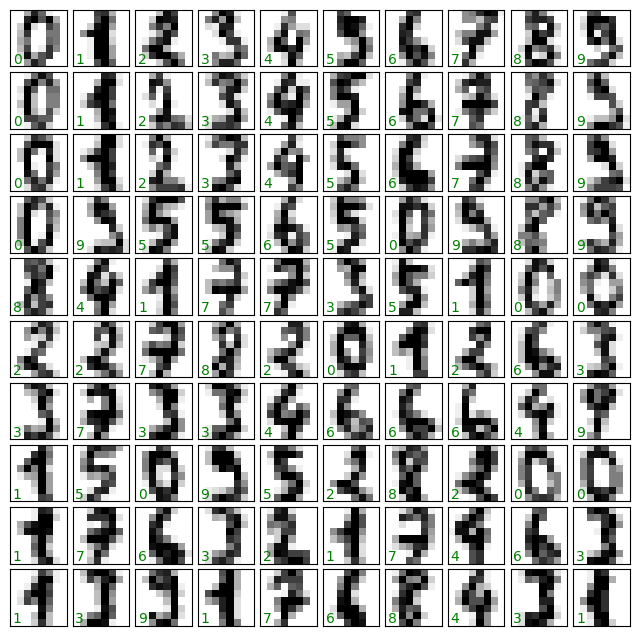

In [66]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(10, 10,figsize=(8, 8),
    subplot_kw={'xticks': [], 'yticks': []},     # 隐藏每个子图的坐标刻度
    gridspec_kw=dict(hspace=0.1, wspace=0.1))    # 设置子图之间的间距
for i, ax in enumerate(axes.flat):    # 依次遍历所有子图
    ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')  # 使用最近邻插值显示图像
    ax.text(0.05, 0.05, str(digits.target[i]),   # 在图像左下角显示数字标签
        transform=ax.transAxes,color='green')    # 使用子图坐标系定位文本

In [67]:
X = digits.data  # 获取展开后的手写数字特征数据
X.shape  # 查看数据形状：(样本数, 特征数)

(1797, 64)

In [68]:
y = digits.target  # 获取每张手写数字图像对应的真实标签
y.shape  # 查看标签数组的形状：(样本数,)

(1797,)

In [69]:
from sklearn.manifold import Isomap  # 导入 Isomap 降维算法
iso = Isomap(n_components=2)  # 创建模型，将数据降到二维
iso.fit(digits.data)  # 使用手写数字数据拟合模型
data_projected = iso.transform(digits.data)  # 将原始数据转换为二维数据
print(data_projected.shape)  # 输出降维后数据的形状

C:\Users\tangy\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\manifold\_isomap.py:362: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\tangy\PyCharmMiscProject\.venv\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


(1797, 2)


C:\Users\tangy\AppData\Local\Temp\ipykernel_8448\2705218363.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('viridis', 10))  # 使用包含 10 种颜色的色图


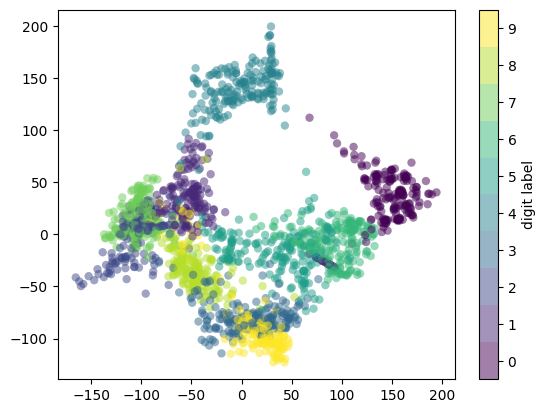

In [70]:
plt.scatter(
    data_projected[:, 0],  # 二维数据的第一个坐标
    data_projected[:, 1],  # 二维数据的第二个坐标
    c=digits.target,  # 根据数字标签设置颜色
    edgecolor='none',  # 不显示散点边框
    alpha=0.5,  # 设置散点透明度
    cmap=plt.cm.get_cmap('viridis', 10))  # 使用包含 10 种颜色的色图
plt.colorbar(label='digit label', ticks=range(10))  # 添加数字标签颜色条
plt.clim(-0.5, 9.5)  # 设置颜色映射范围

In [71]:
from sklearn.model_selection import train_test_split  # 导入数据集划分函数
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, random_state=0)  # 固定随机种子，确保每次划分结果一致

In [72]:
from sklearn.naive_bayes import GaussianNB  # 导入高斯朴素贝叶斯分类器
model = GaussianNB()  # 创建高斯朴素贝叶斯模型
model.fit(Xtrain, ytrain)  # 使用训练集训练模型
y_model = model.predict(Xtest)  # 使用模型预测测试集标签

In [73]:
from sklearn.metrics import accuracy_score  # 导入准确率计算函数
accuracy_score(ytest, y_model)  # 计算模型预测的准确率

0.8333333333333334

Text(113.9222222222222, 0.5, 'true value')

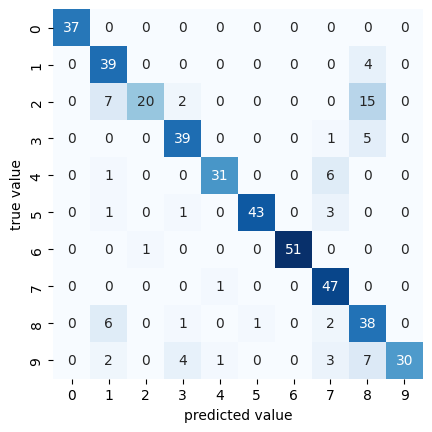

In [74]:
from sklearn.metrics import confusion_matrix  # 导入混淆矩阵函数
import seaborn as sns  # 导入 Seaborn 可视化库
mat = confusion_matrix(ytest, y_model)  # 计算真实标签与预测标签的混淆矩阵
sns.heatmap(
    mat,  # 要绘制的混淆矩阵数据
    square=True,   # 将每个单元格显示为正方形
    annot=True,    # 在单元格中显示具体数值
    cbar=False,    # 不显示右侧颜色条
    cmap='Blues')  # 使用蓝色配色方案
plt.xlabel('predicted value')  # 设置横轴标签：预测值
plt.ylabel('true value')  # 设置纵轴标签：真实值

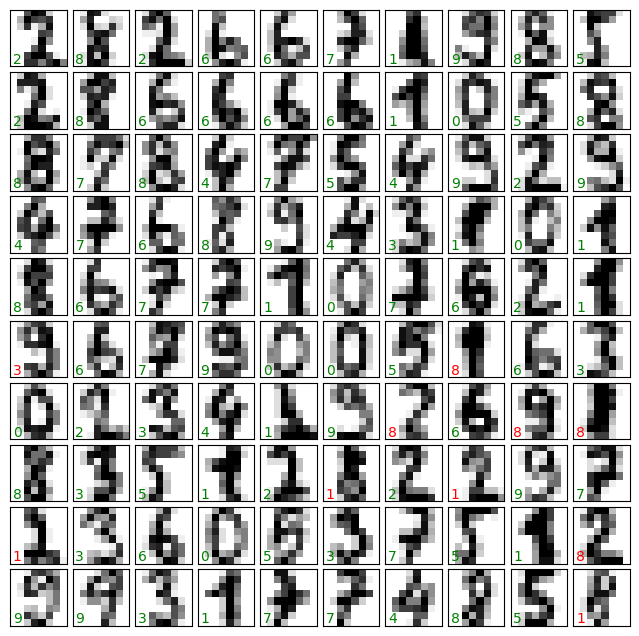

In [75]:
fig, axes = plt.subplots(
    10, 10,  # 创建 10 行 10 列的子图
    figsize=(8, 8),  # 设置整张图的大小
    subplot_kw={'xticks': [], 'yticks': []},  # 隐藏子图坐标刻度
    gridspec_kw=dict(hspace=0.1, wspace=0.1))  # 设置子图之间的间距
test_images = Xtest.reshape(-1, 8, 8)  # 将测试集恢复为 8×8 图像
for i, ax in enumerate(axes.flat):  # 依次遍历所有子图
    ax.imshow(
        test_images[i],  # 显示第 i 张测试图像
        cmap='binary',  # 使用黑白配色
        interpolation='nearest')  # 使用最近邻插值
    ax.text(
        0.05,
        0.05,
        str(y_model[i]),  # 显示模型预测的数字
        transform=ax.transAxes,  # 使用子图坐标系定位文本
        color='green' if ytest[i] == y_model[i] else 'red')  # 正确为绿色，错误为红色